## 오차 역전파
- 순전파 : 입력데이터를 입력층에서 출력층까지 정방향으로 이동시키며 출력값을 예측하는 과정
  - 예측하는 과정
- 역전파 : 출력층에서 발생한 에러를 입력층으로 전파시키면서 최적의 결과를 학습해 나가는 과정
  - 최적의 방향으로 학습하는 과정

- batch_size : 한번의 epoch로는 모든 데이터를 학습하기 어렵기 때문에 나눠서 학습하는 방법
  - batch_size가 작을 수록 메모리 소모는 작음, 학습속도가 느린대신 정확도는 올라 갈 수 있음
  - batch_size가 클수록 메모리 소모는 큼, 학습속도는 빠르나 정확도는 줄어들 수 있음

## 최적화 함수 종류 (Optimizer)
- SGD (확률적 경사 하강법)
  - 오차를 줄여 나갈 수 있도록 확률적으로 선택된 일부 데이터를 업데이트하여 학습하는 방법
- 모멘텀(Momentum)
    - 경사하강법에서 가중치를 수정 할 때 이전 방향을 참고하여 업데이트 하는 방법
    - 지그재그 현상을 줄일 수 있음
    - 학습속도가 가속화 될 가능성이 있음.
- Adagrad
  - 학습을 진행함에 있어 학습률을 점차 줄여나가는 방법
  - 처음에는 학습률을 크게 학습하여 가중치 변동을 크게 진행하고 점점 작게 학습하여 오차에 대해 최적의 해를 찾아 나가는 방법
  - 학습속도가 빠르고 정확하다는 장점이 있음
- Adam
  - 학습에 대해서 학습률을 점차 줄여나가면서 방향 또한 이전 방향을 참고하여 최적의 해를 찾아나가는 방법
  - 현재 가장 많이 사용하는 방법 (장점만을 모았음)

### 오늘의 목표
- 패션 데이터를 가지고 활성화함수, 최적화함수를 변화시키면서 결과를 확인해보는 실습을 진행하기

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
# 현재 작업디렉토리 확인
!pwd

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
# 데이터 다루기 위해 불러오는 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터 가져오기
# sklearn에서 데이터를 제공 했듯이 Tensorflow에서도 데이터셋을 제공한다.
# Tensorflow 에 있는 패션데이터를 불러와보기
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
# 데이터 로드
data = fashion_mnist.load_data()
data

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
# 데이터 분할 (X_train, X_test, y_train, y_test)
X_train = data[0][0]
y_train = data[0][1]
X_test = data[1][0]
y_test = data[1][1]

In [ ]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

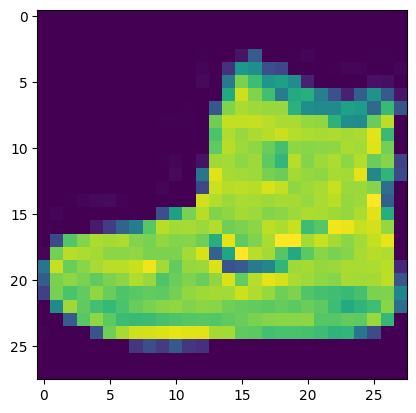

In [ ]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [ ]:
# 정답 데이터 확인
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### 정답데이터 분류
- 0 : 티셔츠
- 1 : 트라우저(바지)
- 2 : 단추가 없는 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌들
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵클 부츠

In [ ]:
y_train[0]

np.uint8(9)

## 신경망 구축
- 데이터 전처리 진행
- MLP 구성

## 이미지 데이터
- 이미지는 2차원(흑백) 또는 3차원(컬러) 형태를 가진다.
- MLP는 1차원 데이터만 학습이 가능하다.
- 이미지 데이터의 차원을 1차원으로 변경해야만 학습이 가능
- reshape : 데이터의 형태를 변형 할 수 있는 기능

## 이미지 전처리 진행
- MLP를 사용하기 위해 이미지의 차원을 1차원으로 변경 (reshape 사용)

In [ ]:
# (28, 28) -> 1차원(784) 변경 진행
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [ ]:
# 데이터 변형하기
X_train_rs = X_train.reshape(60000, 784)
# X_train_rs = X_train.reshape(60000, -1) -> 너가 가진 데이터를 1차원의 형태로 만들어줘

X_test_rs = X_test.reshape(10000, 784)
# X_test_rs = X_test.reshape(60000, -1)

In [ ]:
# 크기확인
print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000,)
(10000,)


In [ ]:
y_train[0]
# 정답데이터를 원핫인코딩으로 변경하는 이유?
# -> 다른 정답에 대한 확률을 알기 위해 원핫인코딩 진행

np.uint8(9)

## 정답데이터 변경
- softmax(다중분류)를 사용하기 위해서는 정답데이터를 원핫인코딩을 해야만 사용 할 수 있다.
- 따라서 y_train, y_test를 원핫인코딩 진행하기


In [ ]:
# 원핫인코딩 진행
y_train_oh = pd.get_dummies(y_train)
y_test_oh = pd.get_dummies(y_test)

In [ ]:
y_train_oh.head()

,0,1,2,3,4,5,6,7,8,9
0,False,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False


### 신경망 설계 (MLP)
- 활성화 함수와 최적화 함수를 설정하여 성능비교 진행

## 1. 활성화함수 : sigmoid / 최적화함수 : SGD

In [ ]:
# 모델을 사용하기 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , InputLayer
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
# 신경망 설계
# 뼈대구축
model1 = Sequential()

# 입력층
model1.add(InputLayer(shape=(784,)))
# InputLayer는 입력층을 받기위한 층이기 때문에, MLP에 전달 할때 원하는 크기로 받을 수 있다.
# 우리가 사용 할때 shape=(28,28)로 사용 가능하다.
# 대신 Flatten 층을 추가
# Flatten : 입력받은 층으로부터 데이터를 1차원으로 변경해서 사용하는 기능

# 중간층
model1.add(Dense(100,activation='sigmoid'))
model1.add(Dense(200,activation='sigmoid'))
model1.add(Dense(100,activation='sigmoid'))

# 출력층
model1.add(Dense(10, activation='softmax'))

In [ ]:
# 학습방법 및 평가방법 설정
model1.compile(
    loss = 'categorical_crossentropy',
    optimizer = SGD(),
    metrics = ['accuracy']
)

In [ ]:
# 학습 진행
model1.fit(
    X_train_rs,
    y_train_oh,
    validation_split = 0.2,
    epochs = 20, # 학습횟수
    batch_size = 64 # 배치사이즈 설정
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3362 - loss: 2.2326 - val_accuracy: 0.5653 - val_loss: 2.1501
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5092 - loss: 2.0075 - val_accuracy: 0.5236 - val_loss: 1.8203
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5581 - loss: 1.6243 - val_accuracy: 0.6418 - val_loss: 1.4491
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6346 - loss: 1.3254 - val_accuracy: 0.6258 - val_loss: 1.2116
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6599 - loss: 1.1257 - val_accuracy: 0.6777 - val_loss: 1.0457
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6776 - loss: 0.9835 - val_accuracy: 0.6948 - val_loss: 0.9250
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6935 - loss: 0.8836 - val_accuracy: 0.7186 - val_loss: 0.8447
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7156 - loss: 0.8071 - val_accuracy: 0.

In [ ]:
# 최적화함수 사용방법
# optimizer = SGD()
# 학습률 조정을 하고 싶을 경우
# SGD(learning_rate = 0.01) -> 0.01 or 0.001 많이 사용 (모델마다 다름)

# 모멘텀 방법으로 학습을 진행하고 싶은경우
# SGD(learning_rate = 0.01, motentum=0.9) # 모멘텀 지수는 일반적으로 0.9를 사용

## 1-1. activation = sigmoid / optimizer = 모멘텀 사용

In [ ]:
# 신경망 설계
print(X_train.shape)
print(X_train_rs.shape)

(60000, 28, 28)
(60000, 784)


In [ ]:
# 만약에 이미지 데이터를 사용 할때 1차원으로 변경 하지 못하고 사용할 경우
# Flatten을 이용하여 1차원으로 전달하는 방법이 존재
from tensorflow.keras.layers import Flatten

In [ ]:
# 뼈대 생성
model2 = Sequential()

# 입력층
model2.add(Flatten(input_shape=(28,28)))
# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달

# 중간층
model2.add(Dense(100, activation='sigmoid'))
model2.add(Dense(200, activation='sigmoid'))
model2.add(Dense(100, activation='sigmoid'))

# 출력층
model2.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)
model2.compile(
    loss='categorical_crossentropy',
    optimizer= SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

In [ ]:
# 학습
model2.fit(
    X_train, y_train_oh,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4975 - loss: 1.4529 - val_accuracy: 0.6056 - val_loss: 1.0077
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6266 - loss: 1.0336 - val_accuracy: 0.6304 - val_loss: 1.0878
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5467 - loss: 1.1840 - val_accuracy: 0.5257 - val_loss: 1.2335
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5194 - loss: 1.1947 - val_accuracy: 0.5452 - val_loss: 1.1246
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4986 - loss: 1.2263 - val_accuracy: 0.5217 - val_loss: 1.2233
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4663 - loss: 1.2852 - val_accuracy: 0.5390 - val_loss: 1.1924
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4879 - loss: 1.2501 - val_accuracy: 0.5093 - val_loss: 1.2460
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4814 - loss: 1.2743 - val_accuracy: 0.

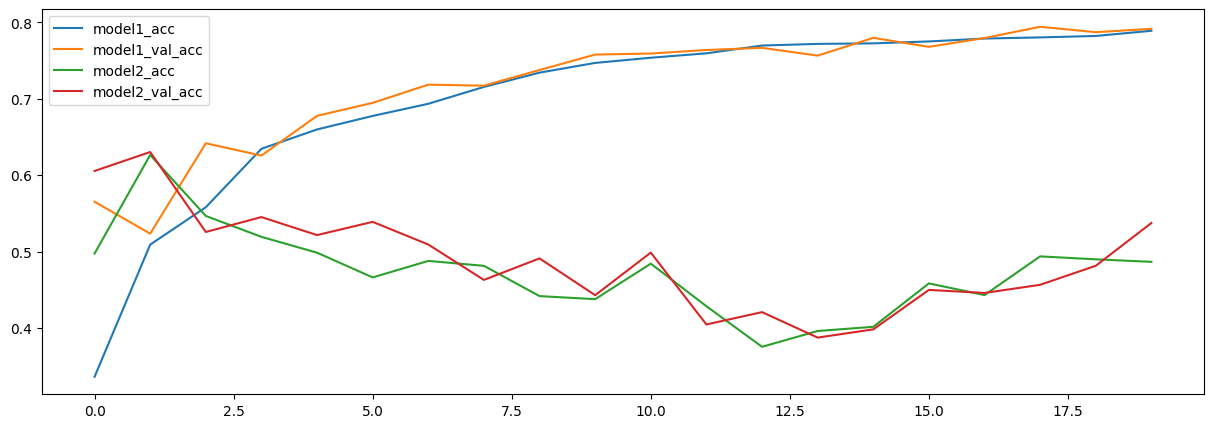

In [ ]:
# 2가지모델 결과비교
plt.figure(figsize=(15,5))

# 1번모델 (sigmoid+SGD)
plt.plot(model1.history.history['accuracy'], label='model1_acc')
plt.plot(model1.history.history['val_accuracy'], label='model1_val_acc')

# 2번모델(sigmoid+모멘텀)
plt.plot(model2.history.history['accuracy'], label='model2_acc')
plt.plot(model2.history.history['val_accuracy'], label='model2_val_acc')

plt.legend()
plt.show()

#### 최적화함수만 다르더라도 결과가 다르게 나올 수 있다. <br>(위의 시각화그래프, 동일모델 최적화함수만 다름)

## 실습
1. 모델 : activation : sigmoid / optimizer : Adam
2. 모델 : activation : Relu / optimizer : SGD
3. 모델 : activation : Relu / optimizer : Adam

In [ ]:
# 모델3
# activation : sigmoid / optimizer : Adam

# 뼈대 생성
model3 = Sequential()

# 입력층
model3.add(Flatten(input_shape=(28,28)))
# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달

# 중간층
model3.add(Dense(100, activation='sigmoid'))
model3.add(Dense(200, activation='sigmoid'))
model3.add(Dense(100, activation='sigmoid'))

# 출력층
model3.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)
model3.compile(
    loss='categorical_crossentropy',
    optimizer= Adam(),
    metrics=['accuracy']
)

In [ ]:
# 학습
model3.fit(
    X_train, y_train_oh,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6111 - loss: 1.0553 - val_accuracy: 0.6804 - val_loss: 0.7997
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7009 - loss: 0.7677 - val_accuracy: 0.7274 - val_loss: 0.7544
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7091 - loss: 0.7483 - val_accuracy: 0.7207 - val_loss: 0.7071
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7131 - loss: 0.7357 - val_accuracy: 0.7153 - val_loss: 0.7441
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7157 - loss: 0.7361 - val_accuracy: 0.7251 - val_loss: 0.7286
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7198 - loss: 0.7288 - val_accuracy: 0.7083 - val_loss: 0.7585
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7278 - loss: 0.7163 - val_accuracy: 0.7261 - val_loss: 0.7210
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7392 - loss: 0.6814 - val_accuracy: 0.

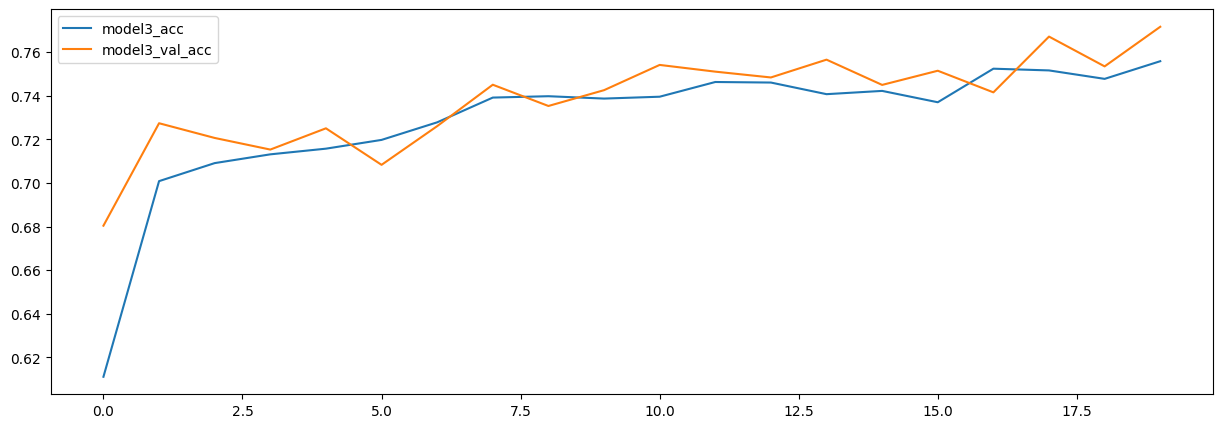

In [ ]:
# 시각화
plt.figure(figsize=(15,5))

# 모델3
plt.plot(model3.history.history['accuracy'], label='model3_acc')
plt.plot(model3.history.history['val_accuracy'], label='model3_val_acc')

plt.legend()
plt.show()

In [ ]:
# 모델4
# activation : Relu / optimizer : SGD

# 뼈대 생성
model4 = Sequential()

# 입력층
model4.add(Flatten(input_shape=(28,28)))
# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달

# 중간층
model4.add(Dense(100, activation='relu'))
model4.add(Dense(200, activation='relu'))
model4.add(Dense(100, activation='relu'))

# 출력층
model4.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)
model4.compile(
    loss='categorical_crossentropy',
    optimizer= SGD(learning_rate = 0.1),
    metrics=['accuracy']
)

In [ ]:
# 학습
model4.fit(
    X_train, y_train_oh,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 9/20
750/750 ━━━━━

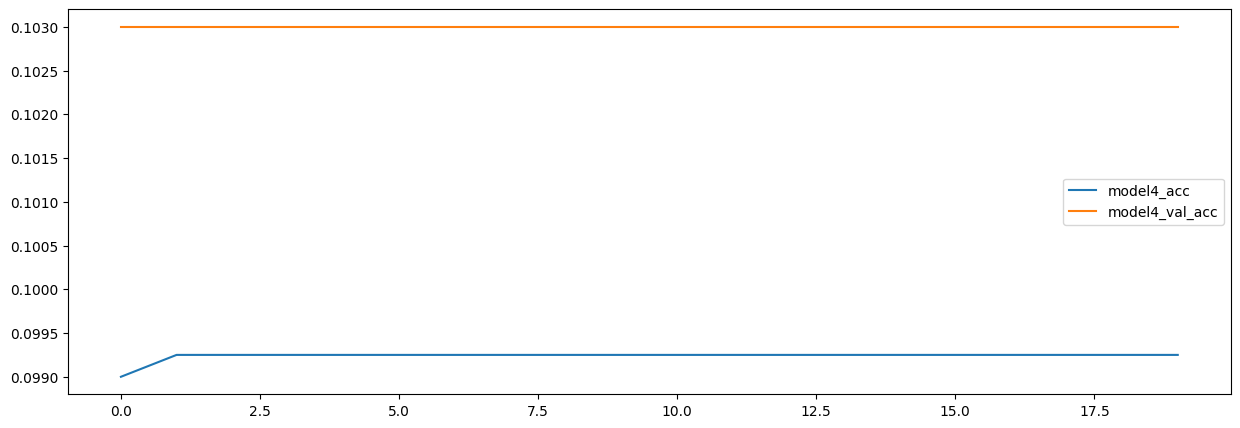

In [ ]:
# 시각화
plt.figure(figsize=(15,5))

# 모델4
plt.plot(model4.history.history['accuracy'], label='model4_acc')
plt.plot(model4.history.history['val_accuracy'], label='model4_val_acc')

plt.legend()
plt.show()

In [ ]:
# 모델5
# activation : Relu / optimizer : Adam

# 뼈대 생성
model5 = Sequential()

# 입력층
model5.add(Flatten(input_shape=(28,28)))
# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달

# 중간층
model5.add(Dense(100, activation='relu'))
model5.add(Dense(200, activation='relu'))
model5.add(Dense(100, activation='relu'))

# 출력층
model5.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)
model5.compile(
    loss='categorical_crossentropy',
    optimizer= Adam(),
    metrics=['accuracy']
)

In [ ]:
# 학습
model5.fit(
    X_train, y_train_oh,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7366 - loss: 1.7493 - val_accuracy: 0.7828 - val_loss: 0.6993
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8044 - loss: 0.5844 - val_accuracy: 0.8087 - val_loss: 0.5693
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8328 - loss: 0.4829 - val_accuracy: 0.8185 - val_loss: 0.5352
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8378 - loss: 0.4578 - val_accuracy: 0.8155 - val_loss: 0.5645
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8500 - loss: 0.4164 - val_accuracy: 0.8435 - val_loss: 0.4489
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8547 - loss: 0.4081 - val_accuracy: 0.8487 - val_loss: 0.4248
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8616 - loss: 0.3799 - val_accuracy: 0.8527 - val_loss: 0.4083
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8661 - loss: 0.3659 - val_accuracy: 0.

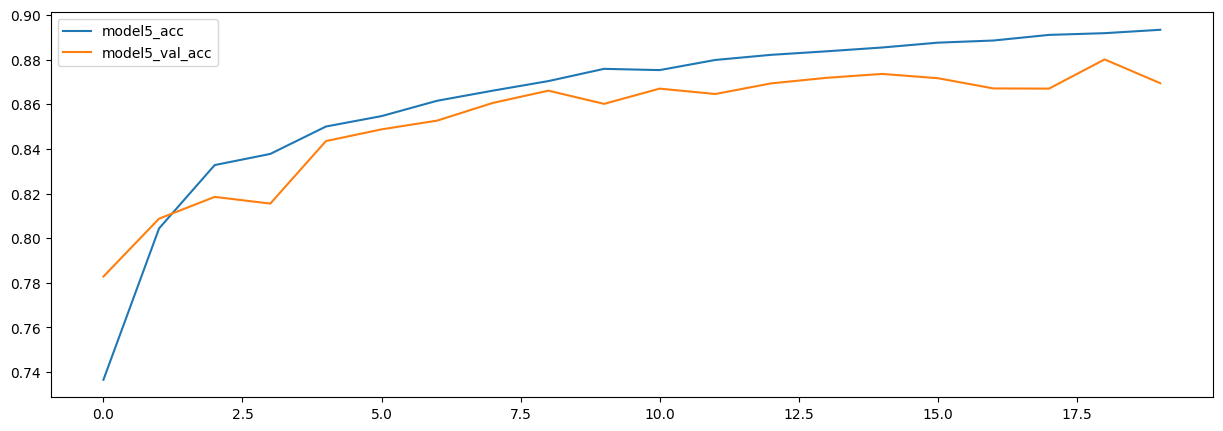

In [ ]:
# 시각화
plt.figure(figsize=(15,5))

# 모델4
plt.plot(model5.history.history['accuracy'], label='model5_acc')
plt.plot(model5.history.history['val_accuracy'], label='model5_val_acc')

plt.legend()
plt.show()

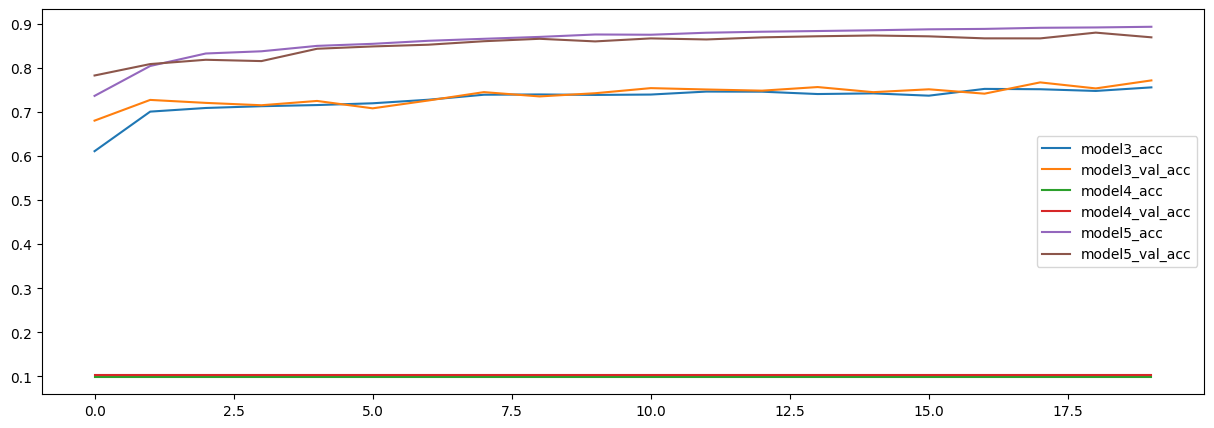

In [ ]:
# 3가지모델 결과비교
plt.figure(figsize=(15,5))

# 모델3
plt.plot(model3.history.history['accuracy'], label='model3_acc')
plt.plot(model3.history.history['val_accuracy'], label='model3_val_acc')

# 모델4
plt.plot(model4.history.history['accuracy'], label='model4_acc')
plt.plot(model4.history.history['val_accuracy'], label='model4_val_acc')

# 모델5
plt.plot(model5.history.history['accuracy'], label='model5_acc')
plt.plot(model5.history.history['val_accuracy'], label='model5_val_acc')

plt.legend()
plt.show()

- 현재 모델에서 성능을 더 올리고 싶다면 다양한 구성으로 변경해서 모델 학습 진행
  - 중간층을 더쌓거나
  - unit개수 증가 시키거나
  - activation에서 learning_rate를 조절